In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [20]:
file = '/eos/user/b/bbapi/MC_contacts/TTG1Jets/CMSSW_15_0_15/src/TTG1Jets_2024_new.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [21]:
len(events)

806536

In [4]:
def draw_side_statboxes(canvas, hists,
                        x1=0.80, x2=0.98,
                        y_top=0.92,
                        box_height=0.18,
                        gap=0.02):
    """
    Draw stacked statboxes on the right side of a canvas.

    Parameters
    ----------
    canvas : ROOT.TCanvas
    hists  : list of ROOT.TH1
    x1,x2  : horizontal NDC range
    y_top  : top starting NDC position
    box_height : height of each box
    gap    : vertical gap between boxes
    """

    # Temporary canvas to force stat creation
    tmp = ROOT.TCanvas("tmp_stats", "", 1, 1)

    orig_stats = {}

    for h in hists:
        h.Draw("hist")
        tmp.Update()

        st = h.GetListOfFunctions().FindObject("stats")
        if not st:
            raise RuntimeError(f"Stats not created for {h.GetName()}")

        orig_stats[h] = st.Clone(f"stats_clone_{h.GetName()}")

    tmp.Close()

    # Disable automatic stat boxes
    ROOT.gStyle.SetOptStat(0)

    canvas.cd()
    canvas.SetRightMargin(0.2)

    # Draw stacked statboxes
    for i, (hst, st) in enumerate(orig_stats.items()):

        st.SetParent(canvas)

        y2 = y_top - i * (box_height + gap)
        y1 = y2 - box_height

        st.SetX1NDC(x1)
        st.SetX2NDC(x2)
        st.SetY1NDC(y1)
        st.SetY2NDC(y2)

        st.SetTextColor(hst.GetLineColor())
        st.SetTextFont(62)   # avoid TTF bug
        st.SetFillStyle(0)
        st.SetBorderSize(1)

        st.Draw()

    canvas.Modified()
    canvas.Update()


In [5]:
Plot_dir = "/eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/"

In [6]:
def CMS_label(pad,
              lumi="109 fb^{-1}",
              year="2024",
              energy="13.6 TeV",
              status="Simulation Preliminary",
              x=0.12,
              y=0.92):

    pad.cd()

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextAngle(0)
    latex.SetTextColor(ROOT.kBlack)

    # ---- CMS (bold) ----
    latex.SetTextFont(61)
    latex.SetTextSize(0.06)
    latex.DrawLatex(x, y, "CMS")

    # ---- Status (italic) ----
    if status != "":
        latex.SetTextFont(52)
        latex.SetTextSize(0.045)
        latex.DrawLatex(x + 0.11, y, status)

    # ---- Lumi text (right aligned) ----
    latex.SetTextFont(42)
    latex.SetTextSize(0.045)
    latex.SetTextAlign(31)
    lumi_text = f"({year}_{lumi})"
    latex.DrawLatex(0.88, y, lumi_text)

In [7]:
def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

In [14]:
# def photon_preselections(
#     photons: ak.Array,
#     jets: ak.Array,
#     electrons: ak.Array,
#     muons: ak.Array,
#     events: ak.Array,
#     electron_veto=True,
#     revert_electron_veto=False,
#     year="2018",
#     wp_medium=0.2783,
#     IsFlag=False):
#     """
#     Apply full preselection on leptons, jets, and photons.
#     Finally return only photons from events that pass all criteria.
#     """

#     print("Number of events before preselection:", len(events))

#     # ------------------------
#     # Lepton selection
#     # ------------------------
#     if year.startswith("2016"):
#         ele_pt_cut, mu_pt_cut = 27, 26
#     elif year == "2017":
#         ele_pt_cut, mu_pt_cut = 33, 29
#     elif year == "2018":
#         # ele_pt_cut, mu_pt_cut = 33, 26
#         ele_pt_cut, mu_pt_cut = 33, 26
#     elif year == "2024":
#         # ele_pt_cut, mu_pt_cut = 33, 26
#         ele_pt_cut, mu_pt_cut = 30, 24

#     else:
#         raise ValueError(f"Unknown year {year}")

#     # electrons = events.Electron

#     good_electrons = (
#         (electrons.pt > ele_pt_cut) &
#         (np.abs(electrons.eta) < 2.5) &  # keep within tracker acceptance
#         ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &  # remove transition
#         (electrons.mvaIso_WP80) &        # tight MVA ID
#         (electrons.pfRelIso03_all < 0.15)  # isolation cut
#     )

#     good_muons = (
#         (muons.pt > mu_pt_cut)
#         & (np.abs(muons.eta) < 2.4)
#         & (muons.pfRelIso03_all < 0.15)
#     )

#     one_ele = ak.num(electrons[good_electrons]) == 1
#     one_mu = ak.num(muons[good_muons]) == 1
#     lepton_channel_mask = one_ele | one_mu
#     # lepton_channel_mask = one_mu

#     selected_electrons = electrons[good_electrons]
#     print("selected_electrons", len(selected_electrons[ak.num(selected_electrons.pt)>0]))
#     selected_muons = muons[good_muons]
#     print("selected_muons", len(selected_muons[ak.num(selected_muons.pt)>0]))
#     selected_leptons = ak.concatenate([selected_electrons, selected_muons], axis=1)
#     print("selected_leptons", len(selected_leptons[ak.num(selected_leptons.pt)>0]))
#     print("selected Electrons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==11])>0]))
#     print("selected Muons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==13])>0]))

#     # ------------------------
#     # Jet selection
#     # ------------------------
#     good_jets = (
#         (jets.pt > 20)
#         & (np.abs(jets.eta) < 2.4)
#         & (jets.btagUParTAK4B > 0.1272)
#     )
#     selected_bjets = jets[good_jets] 
#     print("selected_b_jets: ", selected_bjets)
#     at_least_one_bjets = ak.num(selected_bjets) >= 1
#     # at_least_two_bjets = ak.num(selected_bjets) >= 2

#     # keep top 2 by DeepJet score
#     # top2_bjets = selected_jets[ak.argsort(selected_jets.btagDeepFlavB, ascending=False)][:, :2]

#     # ------------------------
#     # Photon selection (from photon_preselection output)
#     # ------------------------

#     abs_eta = np.abs(photons.eta)

#     # Barrel–endcap transition exclusion (1.442 ≤ |η| ≤ 1.566)
#     valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

#     # Barrel vs Endcap ID cuts
#     is_barrel = abs_eta < 1.442
#     is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

#     # Apply region-specific MVA thresholds
#     barrel_cut = is_barrel & (photons.mvaID > -0.02)
#     endcap_cut = is_endcap & (photons.mvaID > -0.26)

#     # Combine everything
#     good_photons = (
#         (photons.pt > 10)
#         & valid_eta
#         & (barrel_cut | endcap_cut)
#         & (~photons.pixelSeed)
#     )
#     selected_photons = photons[good_photons]
#     at_least_two_photons = ak.num(selected_photons) >= 2

#     dr = delta_r_manual(selected_leptons, selected_photons)
#     dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

#     # ΔR between electrons and photons
#     dr_electrons = delta_r_manual(selected_electrons, selected_photons)

#     # ΔR between muons and photons
#     dr_muons = delta_r_manual(selected_muons, selected_photons)


#     event_mask = lepton_channel_mask & at_least_one_bjets & at_least_two_photons & dr_mask

#     # ------------------------
#     # Apply mask — keep length same, empties for failed events
#     # ------------------------
#     empty_photons = ak.Array([[]] * len(events))
#     empty_bjets = ak.Array([[]] * len(events))
#     empty_leptons = ak.Array([[]] * len(events))

#     filtered_photons = ak.where(event_mask, selected_photons, empty_photons)
#     filtered_jets = ak.where(event_mask, selected_bjets, empty_bjets)
#     filtered_leptons = ak.where(event_mask, selected_leptons, empty_leptons)

#     return event_mask, filtered_photons, filtered_jets, filtered_leptons

In [8]:
def object_preselections(
    photons: ak.Array,
    jets: ak.Array,
    electrons: ak.Array,
    muons: ak.Array,
    year="2018",
):
    """
    Apply object-level preselection only.
    Returns selected photons, bjets, and leptons.
    No event-level requirements applied here.
    """

    # ------------------------
    # Year-dependent lepton pT cuts
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        ele_pt_cut, mu_pt_cut = 30, 24
    else:
        raise ValueError(f"Unknown year {year}")

    # ========================
    # ELECTRONS
    # ========================
    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &
        (electrons.mvaIso_WP80) &
        (electrons.pfRelIso03_all < 0.15)
    )

    selected_electrons = electrons[good_electrons]

    # ========================
    # MUONS
    # ========================
    good_muons = (
        (muons.pt > mu_pt_cut) &
        (np.abs(muons.eta) < 2.4) &
        (muons.pfRelIso03_all < 0.15)
    )

    selected_muons = muons[good_muons]

    # Combine leptons (object level only)
    selected_leptons = ak.concatenate(
        [selected_electrons, selected_muons],
        axis=1
    )

    # ========================
    # BJETS
    # ========================
    good_jets = (
        (jets.pt > 20) &
        (np.abs(jets.eta) < 2.4) &
        (jets.btagUParTAK4B > 0.1272)
    )

    selected_bjets = jets[good_jets]

    # ========================
    # PHOTONS
    # ========================
    abs_eta = np.abs(photons.eta)

    valid_eta = (
        (abs_eta <= 2.5) &
        ~((abs_eta >= 1.442) & (abs_eta <= 1.566))
    )

    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    barrel_cut = is_barrel & (photons.mvaID > 0.0439603)
    endcap_cut = is_endcap & (photons.mvaID > -0.249526)

    good_photons = (
        (photons.pt > 10) &
        valid_eta &
        (barrel_cut | endcap_cut) &
        (~photons.pixelSeed)
    )

    selected_photons = photons[good_photons]

    return selected_photons, selected_bjets, selected_leptons, selected_electrons, selected_muons


In [22]:
selected_photons, selected_bjets, selected_leptons, selected_electrons, selected_muons = object_preselections(
    events.Photon,
    events.Jet,
    events.Electron,
    events.Muon,
    year="2024"
)

one_ele = ak.num(selected_electrons) == 1
one_mu = ak.num(selected_muons) == 1
lepton_channel_mask = one_ele | one_mu
at_least_one_b = ak.num(selected_bjets) >= 1
at_least_two_pho = ak.num(selected_photons) >= 2
dr = delta_r_manual(selected_leptons, selected_photons)
dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

event_mask = lepton_channel_mask & at_least_one_b & at_least_two_pho & dr_mask


In [23]:
sel_events = events[event_mask]

In [24]:
len(sel_events)

2487

In [25]:
gen_parts = sel_events.GenPart

In [26]:
gen_parts.pt*1

<Array [[0, 0, 236, ..., 0.0127, 0.0913], ...] type='2487 * var * float32[p...'>

In [27]:
import particle

In [28]:
gen_parts.pdgId*1

<Array [[21, 2, 22, 6, ..., 22, 11, -11], ...] type='2487 * var * int32[par...'>

In [82]:
particle.Particle.from_pdgid(22)

<Particle: name="gamma", pdgid=22, mass=0.0 MeV>

In [32]:
gen_photons = sel_events.GenPart[
    (sel_events.GenPart.pdgId == 22)
]

In [60]:
gen_photons.hasFlags(["isPrompt"])
# gen_photons.hasFlags(["isHardProcess"])
# gen_photons.hasFlags(["fromHardProcess"])

<Array [[True, True, ..., False, False], ...] type='2487 * var * bool[param...'>

In [63]:
hard_photons = gen_parts[
    (abs(gen_parts.pdgId) == 22) &
    # gen_parts.hasFlags(["fromHardProcess"])
    gen_parts.hasFlags(["isPrompt"])
]

mothers = gen_parts[hard_photons.genPartIdxMother]

In [64]:
np.unique(ak.flatten(mothers.pdgId*1))

<Array [-4122, -431, -421, -411, ..., 421, 431, 445, 4122] type='38 * int32'>

In [66]:
names

['Lambda(c)~-',
 'D(s)-',
 'D~0',
 'D-',
 'K-',
 'pi-',
 'W-',
 'tau+',
 'nu(mu)~',
 'mu+',
 'nu(e)~',
 'e+',
 't~',
 'b~',
 'c~',
 's~',
 'u~',
 'd~',
 'd',
 'u',
 's',
 'c',
 'b',
 't',
 'e-',
 'nu(e)',
 'mu-',
 'nu(mu)',
 'tau-',
 'g',
 'gamma',
 'W+',
 'pi+',
 'D+',
 'D0',
 'D(s)+',
 'chi(c2)(1P)',
 'Lambda(c)+']

In [73]:
np.unique(ak.num(selected_photons[event_mask].pt*1))

<Array [2, 3] type='2 * int64'>

In [81]:
gen_parts[selected_photons[event_mask].genPartIdx*1].pdgId

<Array [[22, 22], [22, 14], ..., [22, 22]] type='2487 * var * int32[paramet...'>

In [87]:
mother_pdg = gen_parts[gen_parts[selected_photons[event_mask].genPartIdx*1].genPartIdxMother].pdgId

In [91]:
mother_ids = ak.flatten(mother_pdg)

from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat_np = np.array(mother_ids)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_selected_phos_TTG1Jets.png")



Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/genPart_selected_phos_TTG1Jets.png has been created


In [92]:
mother_ids = ak.flatten(mother_pdg[mother_pdg!=22])

from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat_np = np.array(mother_ids)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_selected_phos_nonME_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/genPart_selected_phos_nonME_TTG1Jets.png has been created


In [19]:
events.fields

['HLT',
 'RawPFMET',
 'LHEWeight',
 'GenProton',
 'TauSpinner',
 'GenVtx',
 'PuppiMET',
 'TrigObj',
 'Generator',
 'CaloMET',
 'LHE',
 'run',
 'DST',
 'FiducialMET',
 'GenVisTau',
 'HLTriggerFinalPath',
 'LHEPdfWeight',
 'SoftActivityJet',
 'PFCand',
 'GenJet',
 'TauProd',
 'SoftActivityJetHT',
 'Pileup',
 'BeamSpot',
 'boostedTau',
 'HLTriggerFirstPath',
 'SoftActivityJetNjets5',
 'LHEPart',
 'SV',
 'Jet',
 'LHEReweightingWeight',
 'SoftActivityJetNjets2',
 'event',
 'GenPart',
 'FsrPhoton',
 'DeepMETResolutionTune',
 'luminosityBlock',
 'MC',
 'HTXS',
 'GenIsolatedPhoton',
 'SoftActivityJetHT5',
 'GenMET',
 'PSWeight',
 'CorrT1METJet',
 'OtherPV',
 'L1Reco',
 'genTtbarId',
 'TrackGenJetAK4',
 'LowPtElectron',
 'Rho',
 'Photon',
 'Flag',
 'PFMET',
 'FatJet',
 'PV',
 'L1simulation',
 'Electron',
 'PVBS',
 'Tau',
 'SoftActivityJetNjets10',
 'SubGenJetAK8',
 'GenJetAK8',
 'orbitNumber',
 'GenDressedLepton',
 'Dataset',
 'LHEScaleWeight',
 'Muon',
 'RawPuppiMET',
 'IsoTrack',
 'genWeight'

In [20]:
events.Photon.pt*1

<Array [[15.8, 10], [], ..., [27.5, ..., 21.9]] type='571416 * var * float3...'>

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/n_photons_per_event_raw_TTG1Jets.png has been created


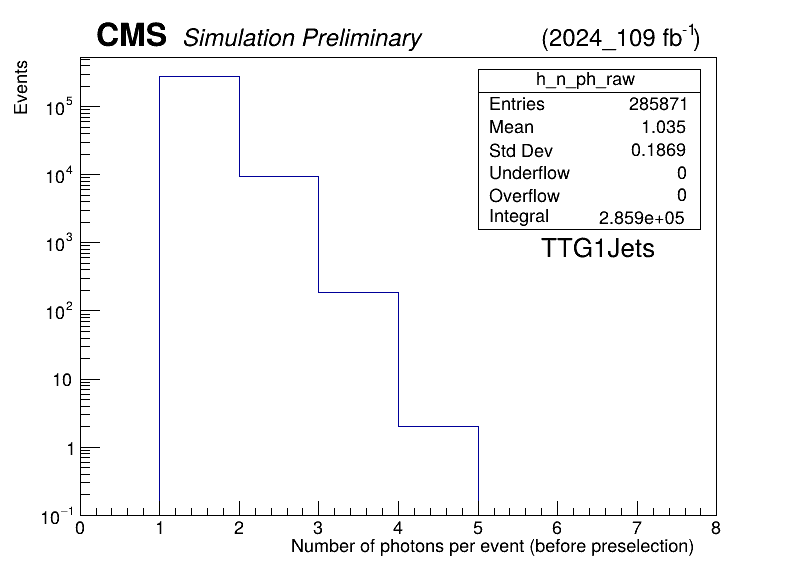

In [21]:
n_ph_raw = ak.to_numpy(ak.num(selected_photons[ak.num(selected_photons.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_ph_raw",
    ";Number of photons per event (before preselection);Events",
    8, 0, 8
)

for v in n_ph_raw:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_ph_raw", "c_n_ph_raw", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_photons_per_event_raw_TTG1Jets.png")


In [22]:
ak.sum(ak.num(selected_photons.pt)==1)

276117

Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xb

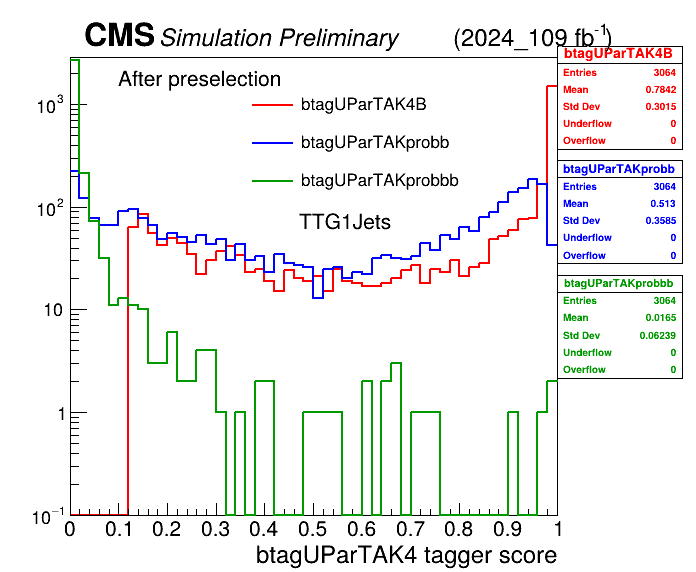

In [23]:
photons = selected_photons

sorted_photons = photons[ak.argsort(photons.pt, ascending=False)]

photons_padded = ak.pad_none(sorted_photons, 2)

lead_photon     = photons_padded[:, 0]
sublead_photon  = photons_padded[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";Photon p_{T} [GeV];Events", 50, 0, 200)
h_sub  = ROOT.TH1F("h_sub",  ";Photon p_{T} [GeV];Events", 50, 0, 200)

# Fill histograms
for pt in ak.drop_none(lead_photon.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_photon.pt):
    h_sub.Fill(pt)


c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, f"Leading #gamma", "l")
leg.AddEntry(h_sub, f"Subleading #gamma", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "Before preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"photons_pt_lead_sublead_raw_TTG1Jets.png")


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/n_jets_per_event_raw_TTG1Jets.png has been created


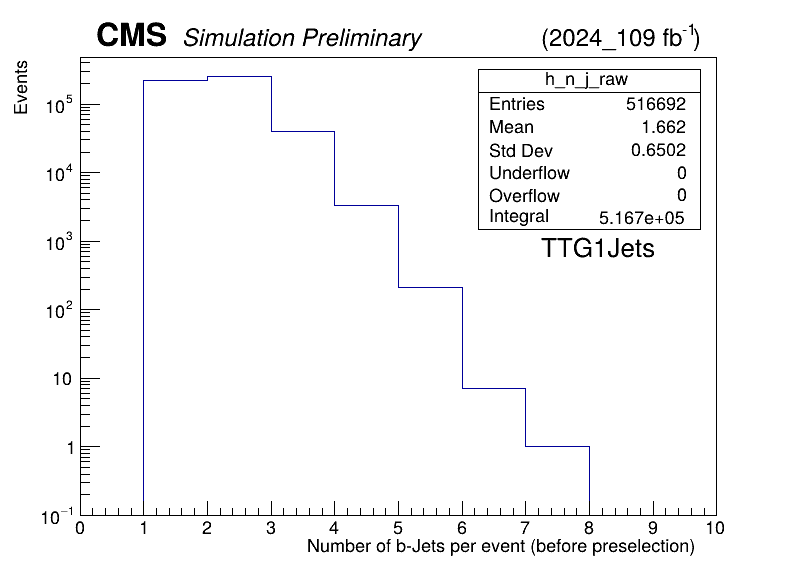

In [24]:
n_j_raw = ak.to_numpy(ak.num(selected_bjets[ak.num(selected_bjets.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_j_raw",
    ";Number of b-Jets per event (before preselection);Events",
    10, 0, 10
)

for v in n_j_raw:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_j_raw", "c_n_j_raw", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_jets_per_event_raw_TTG1Jets.png")


In [25]:
jets = selected_bjets

sorted_jets = jets[ak.argsort(jets.pt, ascending=False)]

jets_padded = ak.pad_none(sorted_jets, 2)

lead_jet     = jets_padded[:, 0]
sublead_jet  = jets_padded[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";b-Jets p_{T} [GeV];Events", 100, 0, 500)
h_sub  = ROOT.TH1F("h_sub",  ";b-Jets p_{T} [GeV];Events", 100, 0, 500)

# Fill histograms
for pt in ak.drop_none(lead_jet.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_jet.pt):
    h_sub.Fill(pt)

c = ROOT.TCanvas("c", "c", 700, 600)
# c.SetLogy()
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

c.Update()

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, "Leading b-Jet", "l")
leg.AddEntry(h_sub, "Subleading b-Jet", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "Before preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"jets_pt_lead_sublead_raw_TTG1Jets.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, ca

In [9]:
evt_mask, fp, fj, fl = event_mask, selected_photons[event_mask], selected_bjets[event_mask], selected_leptons[event_mask]

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/n_photons_per_event_presel_TTG1Jets.png has been created


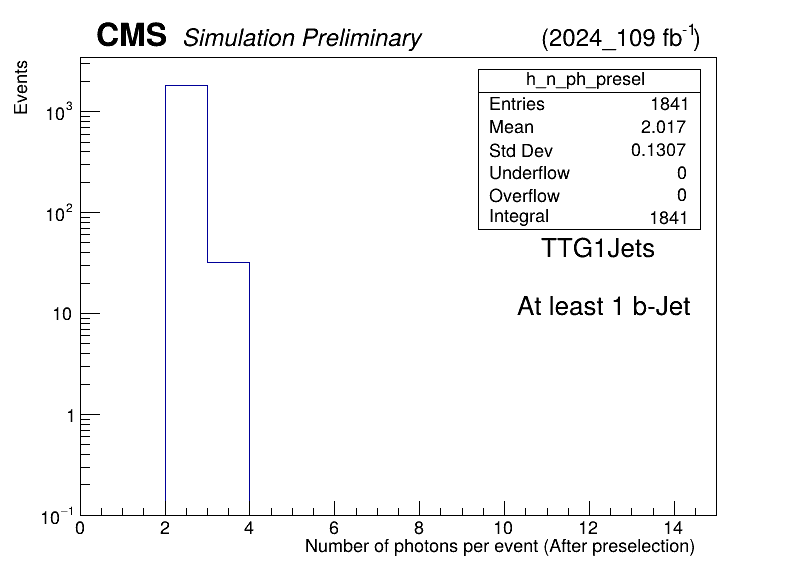

In [27]:
n_ph_presel = ak.to_numpy(ak.num(fp[ak.num(fp.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_ph_presel",
    ";Number of photons per event (After preselection);Events",
    15, 0, 15
)

for v in n_ph_presel:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_ph_presel", "c_n_ph_presel", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")


latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.45, f"At least 1 b-Jet")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_photons_per_event_presel_TTG1Jets.png")


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/n_jets_per_event_presel_TTG1Jets.png has been created


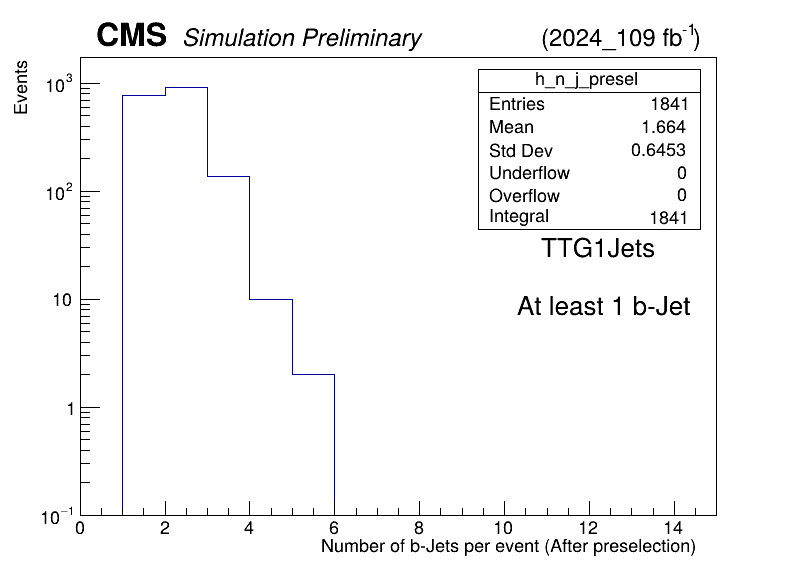

In [28]:
n_j_presel = ak.to_numpy(ak.num(fj[ak.num(fj.pt)>0].pt))   # number of fj per event

# -----------------------------
# Create histogram
# -----------------------------
ROOT.gStyle.SetOptStat(1111111)

h = ROOT.TH1F(
    "h_n_j_presel",
    ";Number of b-Jets per event (After preselection);Events",
    15, 0, 15
)

for v in n_j_presel:
    h.Fill(v)

# -----------------------------
# Draw
# -----------------------------
c = ROOT.TCanvas("c_n_j_presel", "c_n_j_presel", 800, 600)
c.SetLogy()
h.Draw("HIST")
h.SetMinimum(0.1)

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.45, f"At least 1 b-Jet")

CMS_label(c)

# -----------------------------
# Save
# -----------------------------
c.Update()
c.SaveAs(Plot_dir+f"n_jets_per_event_presel_TTG1Jets.png")


In [29]:
sorted_photons_presel = fp[ak.argsort(fp.pt, ascending=False)]

photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

lead_photon_presel     = photons_padded_presel[:, 0]
sublead_photon_presel  = photons_padded_presel[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";Photon p_{T} [GeV];Events", 50, 0, 200)
h_sub  = ROOT.TH1F("h_sub",  ";Photon p_{T} [GeV];Events", 50, 0, 200)

# Fill histograms
for pt in ak.drop_none(lead_photon_presel.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_photon_presel.pt):
    h_sub.Fill(pt)


c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, f"Leading #gamma", "l")
leg.AddEntry(h_sub, f"Subleading #gamma", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "After preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"photons_pt_lead_sublead_presel_TTG1Jets.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, ca

In [30]:
sorted_jets_presel = fj[ak.argsort(fj.pt, ascending=False)]

jets_padded_presel = ak.pad_none(sorted_jets_presel, 2)

lead_jet_presel     = jets_padded_presel[:, 0]
sublead_jet_presel  = jets_padded_presel[:, 1]

ROOT.gStyle.SetOptStat(111111)

h_lead = ROOT.TH1F("h_lead", ";b-Jet p_{T} [GeV];Events", 100, 0, 500)
h_sub  = ROOT.TH1F("h_sub",  ";b-Jet p_{T} [GeV];Events", 100, 0, 500)

# Fill histograms
for pt in ak.drop_none(lead_jet_presel.pt):
    h_lead.Fill(pt)

for pt in ak.drop_none(sublead_jet_presel.pt):
    h_sub.Fill(pt)

c = ROOT.TCanvas("c", "c", 700, 600)
# c.SetLogy()
c.SetLeftMargin(0.12)

max_val = max(h_lead.GetMaximum(), h_sub.GetMaximum())
h_lead.SetMaximum(1.1 * max_val)   # 20% headroom
h_lead.SetMinimum(0)      

h_lead.SetLineColor(ROOT.kRed)
h_lead.SetLineWidth(2)

h_sub.SetLineColor(ROOT.kBlue)
h_sub.SetLineWidth(2)

h_lead.Draw("HIST")
h_sub.Draw("HIST SAME")

c.Update()

draw_side_statboxes(c, [h_lead, h_sub])

leg = ROOT.TLegend(0.50, 0.75, 0.78, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_lead, "Leading b-Jet", "l")
leg.AddEntry(h_sub, "Subleading b-Jet", "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.60, 0.55, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.50, 0.45, "After preselection")

CMS_label(c)

c.SaveAs(Plot_dir+f"jets_pt_lead_sublead_presel_TTG1Jets.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_lead (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_sub (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, ca

In [31]:
one_jet = fj[ak.num(fj.pt)>0]

In [32]:
# =========================
# Build histograms
# =========================
vals = {
    "btagUParTAK4B":      ak.flatten(one_jet.btagUParTAK4B),
    "btagUParTAKprobb":   ak.flatten(one_jet.btagUParTAK4probb),
    "btagUParTAKprobbb":  ak.flatten(one_jet.btagUParTAK4probbb),
}

ROOT.gStyle.SetOptStat(111111)
ROOT.gStyle.SetStatFontSize(0.030)

hists = {}
colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2]

for (name, arr), col in zip(vals.items(), colors):
    h = ROOT.TH1F(name, name, 50, 0, 1)
    h.SetDirectory(0)                 # prevent ROOT ownership
    for x in ak.to_numpy(arr):
        h.Fill(x)
    h.SetLineColor(col)
    h.SetLineWidth(2)
    h.SetMinimum(0.1)
    hists[name] = h

# =========================
# Real canvas + overlay
# =========================
c = ROOT.TCanvas("c", "", 700, 600)
c.SetRightMargin(0.20)
c.SetLogy()

first = True
for h in hists.values():
    h.SetTitle("")
    h.GetXaxis().SetTitle("btagUParTAK4 tagger score")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetXaxis().SetLabelSize(0.04)

    if first:
        h.Draw("hist")
        first = False
    else:
        h.Draw("hist same")

draw_side_statboxes(c, [hists["btagUParTAK4B"], hists["btagUParTAKprobb"], hists["btagUParTAKprobbb"]])

# =========================
# Legend
# =========================
leg = ROOT.TLegend(0.35, 0.65, 0.68, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
for name, h in hists.items():
    leg.AddEntry(h, name, "l")
leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.17, 0.85, f"After preselection")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.43, 0.60, f"TTG1Jets")

CMS_label(c)

# =========================
# Finalize
# =========================
c.Modified()
c.Update()
c.SaveAs(Plot_dir + f"btagger_score_after_presel_TTG1Jets.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error 

In [35]:
ROOT.gStyle.SetOptStat(0)   # no stats box for this plot

n_bjets = ak.num(one_jet.pt)

cat1 = n_bjets >= 2
cat2 = (n_bjets == 1) & (one_jet.btagUParTAK4probbb[:,0] > one_jet.btagUParTAK4probb[:,0])
cat3 = (n_bjets == 1) & (one_jet.btagUParTAK4probb[:,0] > one_jet.btagUParTAK4probbb[:,0])

n_total = len(n_bjets)   # or int(ak.sum(n_jets >= 1)) if already filtered
n_cat1 = int(ak.sum(cat1))
n_cat2 = int(ak.sum(cat2))
n_cat3 = int(ak.sum(cat3))

f_cat1 = round(n_cat1 / n_total,2)
f_cat2 = round(n_cat2 / n_total,2)
f_cat3 = round(n_cat3 / n_total,2)

# --------------------------------
# Create histogram
# --------------------------------
h_frac = ROOT.TH1F(
    "h_frac",
    ";Category;Fraction of Events",
    3, 0, 3
)

h_frac.SetBinContent(1, f_cat1)
h_frac.SetBinContent(2, f_cat2)
h_frac.SetBinContent(3, f_cat3)

# Bin labels
h_frac.GetXaxis().SetBinLabel(1, "#geq 2 bJets")
h_frac.GetXaxis().SetBinLabel(2, "probbb > probb")
h_frac.GetXaxis().SetBinLabel(3, "probb > probbb")

# Style
h_frac.SetFillColor(ROOT.kAzure-9)
h_frac.SetLineColor(ROOT.kBlack)
h_frac.SetLineWidth(2)

h_frac.GetXaxis().SetLabelSize(0.05)
h_frac.GetYaxis().SetLabelSize(0.045)
h_frac.GetYaxis().SetTitleSize(0.03)
# h_frac.GetYaxis().SetTitleOffset(1.3)

h_frac.SetMaximum(1.0)   # fractions go up to 1

# --------------------------------
# Draw
# --------------------------------
c = ROOT.TCanvas("c_frac", "c_frac", 700, 600)
c.SetBottomMargin(0.18)
c.SetLeftMargin(1.3)

h_frac.SetMarkerSize(2.0);
# h_frac.Draw("HIST TEXT0")
h_frac.Draw("HIST")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.17, 0.85, f"After preselection")

latex = ROOT.TLatex()
latex.SetTextAlign(22)   # center
latex.SetTextSize(0.04)
latex.SetTextFont(42)

# Bin centers
for i, (frac, n) in enumerate(
    [(f_cat1, n_cat1), (f_cat2, n_cat2), (f_cat3, n_cat3)],
    start=1
):
    x = h_frac.GetBinCenter(i)
    y = frac + 0.03   # small vertical offset

    text = f"{frac:.2f}  (N={n})"
    latex.DrawLatex(x, y, text)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.73, 0.85, f"TTG1Jets")


c.Update()
c.SaveAs(Plot_dir+f"category_fractions_after_presel_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_frac (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_frac
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/category_fractions_after_presel_TTG1Jets.png has been created


In [243]:
valid_mask = (
    ~ak.is_none(lead_photon_presel.pt) &
    ~ak.is_none(sublead_photon_presel.pt)
)

lead_valid = lead_photon_presel[valid_mask]
sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": lead_valid.pt,
        "eta": lead_valid.eta,
        "phi": lead_valid.phi,
        "mass": ak.zeros_like(lead_valid.pt),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": sublead_valid.pt,
        "eta": sublead_valid.eta,
        "phi": sublead_valid.phi,
        "mass": ak.zeros_like(sublead_valid.pt),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Inclusive category")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/m_gg_presel_TTG1Jets.png has been created


In [211]:
one_photon = fp[ak.num(fp.pt)>0]
cat1_ph = one_photon[cat1]
cat2_ph = one_photon[cat2]
cat3_ph = one_photon[cat3]

In [212]:
sorted_photons_presel = cat1_ph[ak.argsort(cat1_ph.pt, ascending=False)]

photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

lead_photon_presel     = photons_padded_presel[:, 0]
sublead_photon_presel  = photons_padded_presel[:, 1]

valid_mask = (
    ~ak.is_none(lead_photon_presel.pt) &
    ~ak.is_none(sublead_photon_presel.pt)
)

lead_valid = lead_photon_presel[valid_mask]
sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": lead_valid.pt,
        "eta": lead_valid.eta,
        "phi": lead_valid.phi,
        "mass": ak.zeros_like(lead_valid.pt),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": sublead_valid.pt,
        "eta": sublead_valid.eta,
        "phi": sublead_valid.phi,
        "mass": ak.zeros_like(sublead_valid.pt),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 1 (Resolved)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat1_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/m_gg_presel_cat1_TTG1Jets.png has been created


In [213]:
sorted_photons_presel = cat2_ph[ak.argsort(cat2_ph.pt, ascending=False)]

photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

lead_photon_presel     = photons_padded_presel[:, 0]
sublead_photon_presel  = photons_padded_presel[:, 1]

valid_mask = (
    ~ak.is_none(lead_photon_presel.pt) &
    ~ak.is_none(sublead_photon_presel.pt)
)

lead_valid = lead_photon_presel[valid_mask]
sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": lead_valid.pt,
        "eta": lead_valid.eta,
        "phi": lead_valid.phi,
        "mass": ak.zeros_like(lead_valid.pt),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": sublead_valid.pt,
        "eta": sublead_valid.eta,
        "phi": sublead_valid.phi,
        "mass": ak.zeros_like(sublead_valid.pt),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 2 (Merged)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat2_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/m_gg_presel_cat2_TTG1Jets.png has been created


In [214]:
sorted_photons_presel = cat3_ph[ak.argsort(cat3_ph.pt, ascending=False)]

photons_padded_presel = ak.pad_none(sorted_photons_presel, 2)

lead_photon_presel     = photons_padded_presel[:, 0]
sublead_photon_presel  = photons_padded_presel[:, 1]

valid_mask = (
    ~ak.is_none(lead_photon_presel.pt) &
    ~ak.is_none(sublead_photon_presel.pt)
)

lead_valid = lead_photon_presel[valid_mask]
sublead_valid  = sublead_photon_presel[valid_mask]

import vector

vector.register_awkward()

lead_p4 = ak.zip(
    {
        "pt": lead_valid.pt,
        "eta": lead_valid.eta,
        "phi": lead_valid.phi,
        "mass": ak.zeros_like(lead_valid.pt),
    },
    with_name="Momentum4D",
)

sub_p4 = ak.zip(
    {
        "pt": sublead_valid.pt,
        "eta": sublead_valid.eta,
        "phi": sublead_valid.phi,
        "mass": ak.zeros_like(sublead_valid.pt),
    },
    with_name="Momentum4D",
)


diphoton = lead_p4 + sub_p4

m_gg=diphoton.mass

# Convert to numpy
m_gg_np = ak.to_numpy(m_gg)

# Create histogram
h = ROOT.TH1F("h",
            ";m_{#gamma#gamma} (GeV);Events",
            60, 0, 200)

# Fill
for val in m_gg_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_gg",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

ROOT.gStyle.SetOptStat(1111111)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.05)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.55, f"TTG1Jets")

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.45, "Category 3 (One lost)")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.68, 0.50, "After preselection")

c.Draw()

c.Update()

stats = h.FindObject("stats")
if stats:
    stats.SetTextSize(0.035)     # enlarge text
    stats.SetX1NDC(0.60)         # left
    stats.SetX2NDC(0.88)         # right
    stats.SetY1NDC(0.60)         # bottom
    stats.SetY2NDC(0.88)         # top
    stats.SetBorderSize(1)

c.SaveAs(Plot_dir+f"m_gg_presel_cat3_TTG1Jets.png")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/m_gg_presel_cat3_TTG1Jets.png has been created


In [10]:
gen = events[event_mask].GenPart

bjet_idx = selected_bjets[event_mask].genJetIdx
gen_bjets = gen[bjet_idx]

mother_bjets = gen[gen_bjets.genPartIdxMother]

mpdg_bjets_presel = mother_bjets.pdgId

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/genPart_b-Jets_presel_TTG1Jets.png has been created


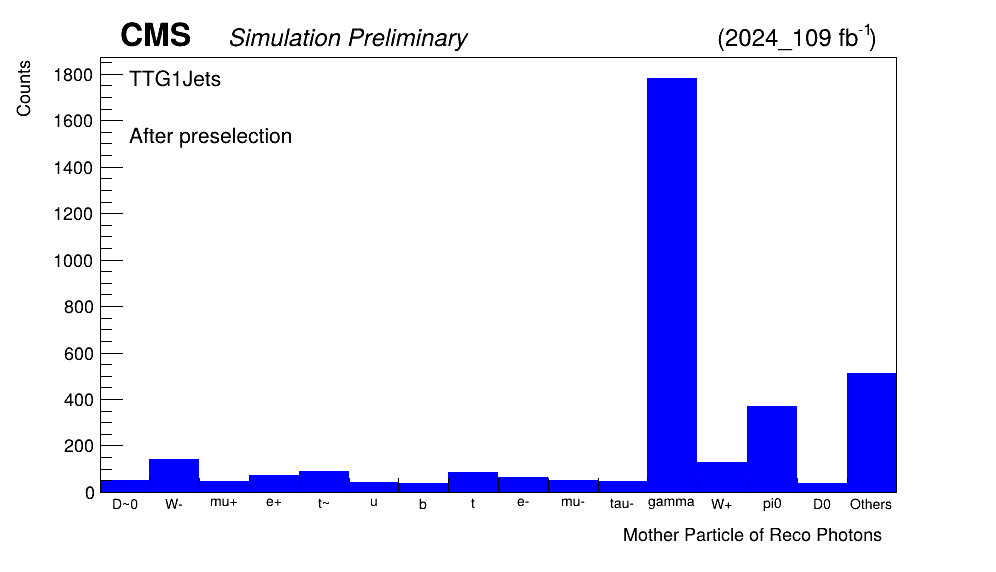

In [11]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg_bjets_presel)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco b-Jets;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_b-Jets_presel_TTG1Jets.png")



In [12]:
gen_presel = events[event_mask].GenPart

pho_idx = selected_photons[event_mask].genPartIdx
gen_photons = gen_presel[pho_idx]

mother = gen_presel[gen_photons.genPartIdxMother]

mpdg_presel = mother.pdgId


In [13]:
from particle import Particle

# ---------------------------------
# Use your real jagged array here
# mother_pdgId = ...
# ---------------------------------

# Flatten jagged array
flat = ak.flatten(mpdg_presel)
flat_np = np.array(flat)

# Count unique PDG IDs
unique_ids, counts = np.unique(flat_np, return_counts=True)
total = np.sum(counts)

# Keep only major contributors (>1%)
threshold = 0.01
major_ids = []
major_counts = []
others_count = 0

for pid, cnt in zip(unique_ids, counts):
    if cnt / total > threshold:
        major_ids.append(pid)
        major_counts.append(cnt)
    else:
        others_count += cnt

if others_count > 0:
    major_ids.append(999999)
    major_counts.append(others_count)

# Create histogram
n_bins = len(major_ids)
h = ROOT.TH1F(
    "h",
    ";Mother Particle of Reco Photons;Counts",
    n_bins,
    0,
    n_bins
)
h.GetXaxis().SetTitleOffset(1.3)
h.SetLabelSize(0.04)
h.SetFillColor(ROOT.kBlue)

# Fill histogram with particle names
for i, (pid, cnt) in enumerate(zip(major_ids, major_counts), start=1):

    if pid == 999999:
        label = "Others"
    else:
        try:
            label = Particle.from_pdgid(int(pid)).name
        except:
            label = str(pid)

    h.GetXaxis().SetBinLabel(i, label)
    h.SetBinContent(i, cnt)

# Draw
ROOT.gStyle.SetOptStat(0)
c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.14)
h.Draw("bar")
CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.85, f"TTG1Jets")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.13, 0.75, "After preselection")

c.Update()

c.SaveAs(Plot_dir + "genPart_photons_presel_TTG1Jets.png")



Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Background_study_2024/TTG1Jets/genPart_photons_presel_TTG1Jets.png has been created
